# MICROPROYECTO 1 con tensorflow
## Clasificación de imágenes médicas para detectar tumores cerebrales utilizando Redes Neuronales Convolucionales (CNN)
Presentado por: 
Victoria Herrera Galvis
Marco Torres
Marcelo Torres

Este microproyecto tiene como objetivo  detectar distintos tipos de tumores cerebrales a partir de imágenes de resonancia magnética (MRI), usando un modelo de clasificación de imágenes médicas utilizando Redes Neuronales Convolucionales (CNN).

El modelo será entrenado para clasificar cada imagen en una de las siguientes categorías:

- Glioma
- Meningioma
- Tumor pituitario
- Tejido sano

Las CNN permiten extraer patrones visuales complejos como bordes, texturas y formas, lo que las hace especialmente efectivas en tareas de diagnóstico asistido por imágenes. Este enfoque busca mejorar la precisión, consistencia y velocidad en la clasificación, sirviendo como apoyo en contextos médicos.

El dataset utilizado contiene 7023 imágenes de MRI, y será dividido en conjuntos de entrenamiento y prueba para evaluar el desempeño del modelo.

Para desarrollar el modelo se abordarán las siguientes fases:

1. Importación de librerías
2. Carga del dataset
3. Exploración  del dataset
4. Procesamiento de imágenes
5. División del dataset
6. Diseño del modelo CNN
7. Preparación del modelo para entrenamiento
8. Entrenamiento
9. Evaluación del modelo
10. Analisis de resultados y Comparación de modelos
11. Mejoras
12. Conclusiones

## 1. Importación de librerías

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

# Fijar semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

2026-04-18 12:20:15.473410: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.15.0
GPU disponible: []


## 2. Carga y exploración del dataset

El dataset [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) contiene 7023 imágenes divididas en 4 clases: **glioma**, **meningioma**, **pituitary** y **notumor**.  
Ya viene con carpetas `Training/` y `Testing/` separadas — las usaremos directamente.

In [2]:

# ruta

DATASET_ROOT = "/Users/victoriaherrera/Documents/Estudios/Maestria/Tecnicas de Deep Learning/Microproyecto1/brain_tumor_dataset"   

CLASS_NAMES = sorted(os.listdir(DATASET_ROOT))
NUM_CLASSES = len(CLASS_NAMES)
print("Clases encontradas:", CLASS_NAMES)
print("Número de clases:", NUM_CLASSES)

Clases encontradas: ['glioma', 'healthy', 'meningioma', 'pituitary']
Número de clases: 4


In [3]:
# ------------------------------------------------------------
# Conteo de imágenes por clase (train y test)
# ------------------------------------------------------------
def count_images(directory):
    """Cuenta imágenes por clase en un directorio con subcarpetas."""
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            imgs = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            counts[cls] = len(imgs)
    return counts

df_counts = count_images(DATASET_ROOT)


print("DATASET:")
for cls, n in df_counts.items():
    print(f"  {cls:12s}: {n} imágenes")
print(f"  TOTAL       : {sum(df_counts.values())}")



DATASET:
  glioma      : 1621 imágenes
  healthy     : 2000 imágenes
  meningioma  : 1645 imágenes
  pituitary   : 1757 imágenes
  TOTAL       : 7023


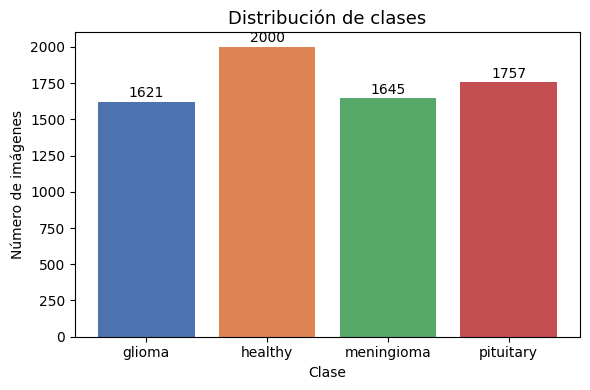

In [4]:
# ------------------------------------------------------------
# Visualizar distribución de clases
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(df_counts.keys(), df_counts.values(),
              color=['#4C72B0','#DD8452','#55A868','#C44E52'])

ax.set_title('Distribución de clases', fontsize=13)
ax.set_ylabel('Número de imágenes')
ax.set_xlabel('Clase')

for bar, val in zip(bars, df_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fig1_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

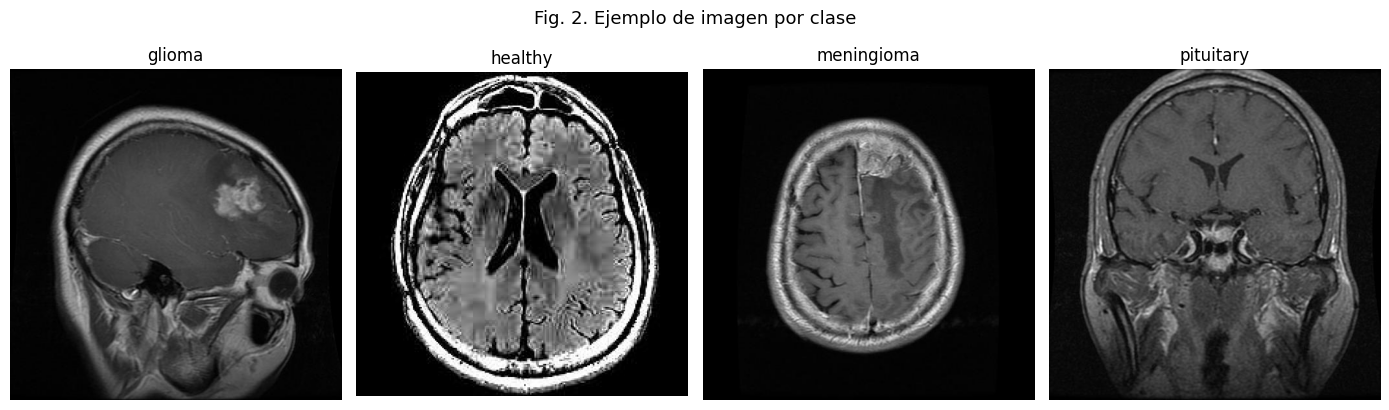

In [5]:
# ------------------------------------------------------------
# Visualizar un ejemplo de imagen por clase
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, cls in zip(axes, CLASS_NAMES):
    cls_path = os.path.join(DATASET_ROOT, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    img_path = os.path.join(cls_path, imgs[0])
    img = plt.imread(img_path)
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax.set_title(cls, fontsize=12)
    ax.axis('off')

plt.suptitle('Fig. 2. Ejemplo de imagen por clase', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig2_ejemplos_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocesamiento y pipeline de datos

- **Redimensionado de tamaño de imagen:** de 512 x 512 px a 224×224 px (compatible con EfficientNetB0)
- **Normalización:** escalado [0,1] mediante `rescale=1./255`
- **Data Augmentation en train:** flip horizontal, rotación ±15°, zoom ±10%, desplazamiento ±10%
- **Split:** Se usa la carpeta `Training` (con 20% separado para validación) y `Testing` como test final.
- **Batch size:** 32

In [6]:
import os
import shutil
import random 
# Rutas
# ------------------------------------------------------------
DATASET_ROOT = "/Users/victoriaherrera/Documents/Estudios/Maestria/Tecnicas de Deep Learning/Microproyecto1/brain_tumor_dataset"

BASE_OUTPUT = "/Users/victoriaherrera/Documents/Estudios/Maestria/Tecnicas de Deep Learning/Microproyecto1"

TRAIN_DIR = os.path.join(BASE_OUTPUT, "TRAIN_DIR")
TEST_DIR  = os.path.join(BASE_OUTPUT, "TEST_DIR")

# ------------------------------------------------------------
# Parámetros
# ------------------------------------------------------------
SPLIT_RATIO = 0.8
SEED = 42

random.seed(SEED)

# ------------------------------------------------------------
# Crear estructura de carpetas
# ------------------------------------------------------------
for split_dir in [TRAIN_DIR, TEST_DIR]:
    for class_name in os.listdir(DATASET_ROOT):
        class_path = os.path.join(DATASET_ROOT, class_name)

        if os.path.isdir(class_path):
            os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)

# ------------------------------------------------------------
# Dividir imágenes
# ------------------------------------------------------------
for class_name in os.listdir(DATASET_ROOT):
    class_path = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_path):
        continue

    # Filtrar imágenes válidas
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    random.shuffle(images)

    split_idx = int(len(images) * SPLIT_RATIO)

    train_images = images[:split_idx]
    test_images  = images[split_idx:]

    # Copiar a TRAIN_DIR
    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(TRAIN_DIR, class_name, img)
        )

    # Copiar a TEST_DIR
    for img in test_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(TEST_DIR, class_name, img)
        )

print("✅ Dataset dividido en TRAIN_DIR y TEST_DIR correctamente")

✅ Dataset dividido en TRAIN_DIR y TEST_DIR correctamente


In [7]:
# ------------------------------------------------------------
# Hiperparámetros del pipeline
# ------------------------------------------------------------
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32
VAL_SPLIT  = 0.2    # 20% de Training para validación
SEED = 42
# Data Augmentation solo para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    fill_mode='nearest'
)

# Validación y test: SOLO normalización, sin augmentation
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Generador de entrenamiento (80% de Training)
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

# Generador de validación (20% de Training)
val_gen = val_test_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Generador de test (carpeta Testing, sin augmentation)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nÍndice de clases:", train_gen.class_indices)
print(f"Train:      {train_gen.samples} imágenes")
print(f"Validación: {val_gen.samples} imágenes")
print(f"Test:       {test_gen.samples} imágenes")

Found 4494 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 1406 images belonging to 4 classes.

Índice de clases: {'glioma': 0, 'healthy': 1, 'meningioma': 2, 'pituitary': 3}
Train:      4494 imágenes
Validación: 1123 imágenes
Test:       1406 imágenes


## 4. Arquitectura del modelo — Fine-tuning EfficientNetB0

Se utiliza **EfficientNetB0** preentrenado en ImageNet como extractor de características.  
- Las capas base se **congelan** en la primera fase del entrenamiento.
- Se reemplaza la cabeza clasificadora por una propia de 4 clases.
- En la segunda fase se realiza **fine-tuning** descongelando las últimas capas de la base.

In [9]:
pip install certifi

Note: you may need to restart the kernel to use updated packages.


In [12]:
import ssl
import certifi

ssl._create_default_https_context = ssl.create_default_context(cafile=certifi.where())

In [13]:
# ------------------------------------------------------------
# Construcción del modelo con EfficientNetB0
# ------------------------------------------------------------
def build_model(num_classes=4, img_size=(224, 224, 3), freeze_base=True):
    """
    Construye un modelo de clasificación usando EfficientNetB0 como base.
    
    Parámetros:
        num_classes  : número de categorías de salida
        img_size     : dimensiones de entrada (H, W, C)
        freeze_base  : si True, congela los pesos de la base preentrenada
    Retorna:
        model        : modelo Keras compilado
    """
    # Base preentrenada en ImageNet
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=img_size
    )
    base_model.trainable = not freeze_base

    # Cabeza clasificadora
    inputs = tf.keras.Input(shape=img_size)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='EfficientNetB0_BrainTumor')
    return model

# Construir modelo con base congelada
model = build_model(num_classes=NUM_CLASSES)
model.summary()

total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nParámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

TypeError: 'SSLContext' object is not callable

## 5. Fase 1 — Entrenamiento con base congelada

- **Función de pérdida:** `categorical_crossentropy` (clasificación multiclase con one-hot)
- **Optimizador:** Adam con lr=1e-3
- **Épocas:** 15
- **Callbacks:** EarlyStopping y ModelCheckpoint para guardar el mejor modelo

In [ ]:
# ------------------------------------------------------------
# Compilación — Fase 1
# ------------------------------------------------------------
LR_FASE1 = 1e-3
EPOCHS_FASE1 = 15

model.compile(
    optimizer=Adam(learning_rate=LR_FASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
cb_early = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
)
cb_ckpt = callbacks.ModelCheckpoint(
    'best_model_fase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)

# Entrenamiento Fase 1
history1 = model.fit(
    train_gen,
    epochs=EPOCHS_FASE1,
    validation_data=val_gen,
    callbacks=[cb_early, cb_ckpt],
    verbose=1
)

print("\nFase 1 completada.")

## 6. Fase 2 — Fine-tuning (descongelar últimas capas)

Se descongelan las últimas 30 capas de EfficientNetB0 con un learning rate más bajo (1e-5) para ajustar los pesos al dominio médico.

In [ ]:
# ------------------------------------------------------------
# Fine-tuning — Fase 2
# ------------------------------------------------------------
FINE_TUNE_FROM = 100   # Descongelar capas a partir de este índice
LR_FASE2   = 1e-5
EPOCHS_FASE2 = 10

# Descongelar base parcialmente
base_model = model.layers[1]   # EfficientNetB0 es el segundo layer
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

trainable_now = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Parámetros entrenables en Fase 2: {trainable_now:,}")

# Recompilar con lr más bajo
model.compile(
    optimizer=Adam(learning_rate=LR_FASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_ckpt2 = callbacks.ModelCheckpoint(
    'best_model_final.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)

history2 = model.fit(
    train_gen,
    epochs=EPOCHS_FASE2,
    validation_data=val_gen,
    callbacks=[cb_early, cb_ckpt2],
    verbose=1
)

print("\nFine-tuning completado.")

## 7. Curvas de entrenamiento

In [ ]:
# ------------------------------------------------------------
# Combinar historiales Fase 1 + Fase 2
# ------------------------------------------------------------
def merge_histories(h1, h2):
    """Concatena dos historiales de entrenamiento de Keras."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

hist = merge_histories(history1, history2)
epoch_range = range(1, len(hist['accuracy']) + 1)
finetune_start = len(history1.history['accuracy'])

# ------------------------------------------------------------
# Figura: curvas de loss y accuracy
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, ylabel in zip(
    axes,
    [('accuracy','val_accuracy'), ('loss','val_loss')],
    ['Accuracy', 'Loss']
):
    train_key, val_key = metric
    ax.plot(epoch_range, hist[train_key], label='Train', color='#4C72B0', linewidth=2)
    ax.plot(epoch_range, hist[val_key],   label='Val',   color='#DD8452', linewidth=2)
    ax.axvline(x=finetune_start + 0.5, color='gray', linestyle='--', alpha=0.7,
               label='Inicio fine-tuning')
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Curvas de {ylabel}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Fig. 3. Evolución del entrenamiento (Fase 1 + Fine-tuning)', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluación en conjunto de test

In [ ]:
# ------------------------------------------------------------
# Cargar el mejor modelo y evaluar en test
# ------------------------------------------------------------
best_model = tf.keras.models.load_model('best_model_final.keras')

# Evaluar pérdida y accuracy en test
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

In [ ]:
# ------------------------------------------------------------
# Predicciones y métricas detalladas
# ------------------------------------------------------------
# Resetear el generador para asegurar orden correcto
test_gen.reset()

y_pred_probs = best_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

In [ ]:
# ------------------------------------------------------------
# Matriz de confusión (resultados cuantitativos)
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Etiqueta real', fontsize=12)
ax.set_title('Fig. 4. Matriz de confusión en test', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Resultados cualitativos — Aciertos y fallos del modelo

Se muestran ejemplos de imágenes **correctamente clasificadas** e **incorrectamente clasificadas** por el modelo.

In [ ]:
# ------------------------------------------------------------
# Obtener rutas de imágenes de test con sus predicciones
# ------------------------------------------------------------
test_paths = test_gen.filepaths

# Separar aciertos y fallos
correct_mask = (y_pred == y_true)
wrong_mask   = ~correct_mask

correct_indices = np.where(correct_mask)[0]
wrong_indices   = np.where(wrong_mask)[0]

print(f"Aciertos: {correct_mask.sum()} / {len(y_true)}")
print(f"Fallos:   {wrong_mask.sum()} / {len(y_true)}")

In [ ]:
# ------------------------------------------------------------
# Función auxiliar para mostrar imágenes con etiquetas
# ------------------------------------------------------------
def show_predictions(indices, title, n_cols=4, figname='fig_qual.png'):
    """
    Muestra imágenes con predicción vs ground truth.
    Parámetros:
        indices  : array de índices a mostrar
        title    : título de la figura
        n_cols   : número de columnas (una por clase)
        figname  : nombre del archivo de salida
    """
    sample = np.random.choice(indices, size=min(n_cols, len(indices)), replace=False)
    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4))
    if len(sample) == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample):
        img = plt.imread(test_paths[idx])
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        pred_cls  = CLASS_NAMES[y_pred[idx]]
        true_cls  = CLASS_NAMES[y_true[idx]]
        color     = 'green' if pred_cls == true_cls else 'red'
        ax.set_title(
            f"Pred: {pred_cls}\nReal: {true_cls}",
            fontsize=10, color=color
        )
        ax.axis('off')

    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(figname, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ------------------------------------------------------------
# Fig. 5: Ejemplos correctamente clasificados (1 por clase)
# ------------------------------------------------------------
print("Fig. 5 — Ejemplos correctamente clasificados")
per_class_correct = []
for cls_idx in range(NUM_CLASSES):
    cls_correct = np.where((y_true == cls_idx) & correct_mask)[0]
    if len(cls_correct) > 0:
        per_class_correct.append(np.random.choice(cls_correct))

show_predictions(
    np.array(per_class_correct),
    'Fig. 5. Ejemplos correctamente clasificados (verde = correcto)',
    figname='fig5_aciertos.png'
)

In [ ]:
# ------------------------------------------------------------
# Fig. 6: Ejemplos incorrectamente clasificados
# ------------------------------------------------------------
print("Fig. 6 — Ejemplos incorrectamente clasificados")
if len(wrong_indices) >= 4:
    show_predictions(
        wrong_indices,
        'Fig. 6. Ejemplos incorrectamente clasificados (rojo = error)',
        n_cols=4,
        figname='fig6_fallos.png'
    )
else:
    print(f"Solo hay {len(wrong_indices)} fallos en test — el modelo clasifica muy bien.")

## 10. Resumen de resultados

Tabla resumen con todas las métricas para incluir en el informe IEEE.

In [ ]:
# ------------------------------------------------------------
# Tabla resumen de métricas (para copiar al informe)
# ------------------------------------------------------------
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES)
)
overall_acc = accuracy_score(y_true, y_pred)

print("=" * 65)
print(f"{'Clase':<14} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Soporte':>9}")
print("=" * 65)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:<14} {precision[i]:>10.4f} {recall[i]:>8.4f} {f1[i]:>8.4f} {support[i]:>9}")
print("-" * 65)
print(f"{'Accuracy':<14} {'':<10} {'':<8} {overall_acc:>8.4f} {len(y_true):>9}")
print("=" * 65)

print(f"\nHiperparámetros usados:")
print(f"  Arquitectura : EfficientNetB0 + fine-tuning")
print(f"  Input size   : {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  LR Fase 1    : {LR_FASE1}")
print(f"  LR Fase 2    : {LR_FASE2}")
print(f"  Épocas F1    : {EPOCHS_FASE1} (con EarlyStopping)")
print(f"  Épocas F2    : {EPOCHS_FASE2} (con EarlyStopping)")
print(f"  Fine-tune desde capa: {FINE_TUNE_FROM}")